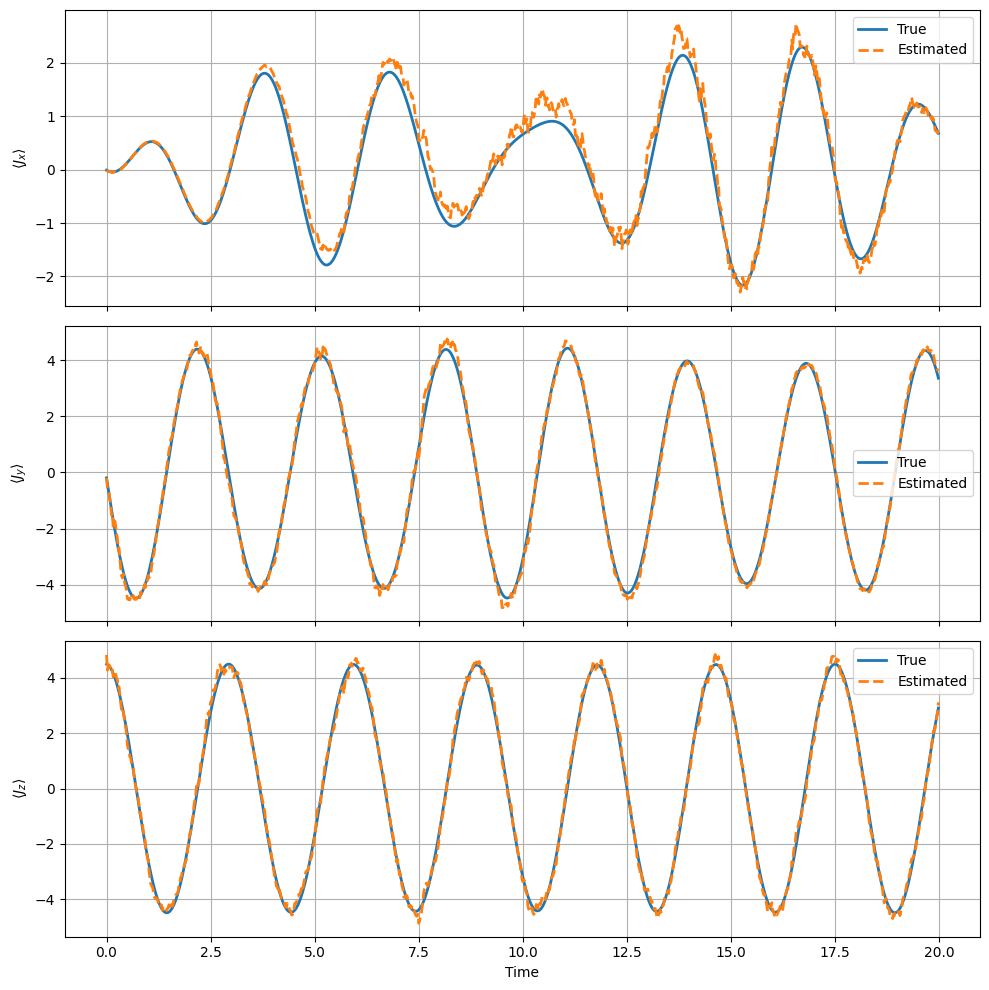

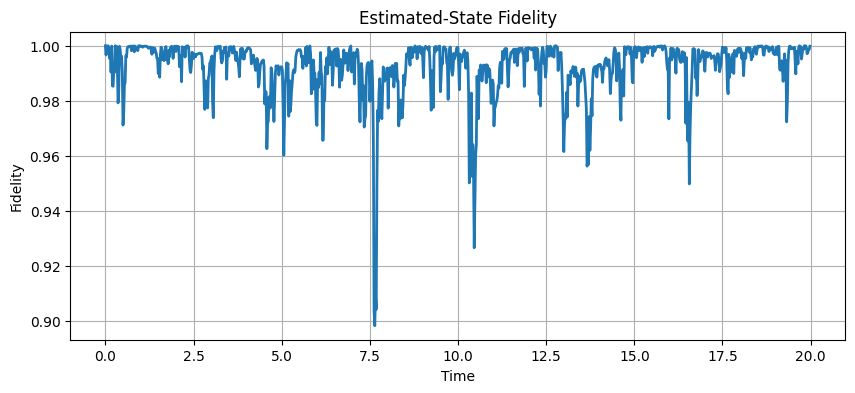

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ============================================================
# Spin-9/2 operators
# ============================================================

j = 9 / 2

dim = int(2 * j + 1)

m_vals = np.arange(j, -j - 1, -1)

Jp = np.zeros((dim, dim), dtype=complex)
Jm = np.zeros((dim, dim), dtype=complex)
Jz = np.diag(m_vals)

for i, m in enumerate(m_vals[:-1]):
    coeff = np.sqrt(j * (j + 1) - m * (m - 1))
    Jm[i + 1, i] = coeff

Jp = Jm.conj().T

Jx = 0.5 * (Jp + Jm)
Jy = -0.5j * (Jp - Jm)

# ============================================================
# Initial spin coherent state along +z
# ============================================================

psi0 = np.zeros(dim, dtype=complex)
psi0[0] = 1.0

# ============================================================
# Simulation parameters
# ============================================================

Omega = 1.0
omega_x = 0.15
omega_y = -0.12
omega_z = 0.2

T = 20.0
dt = 0.02
N = int(T / dt)

time = np.arange(N) * dt

# Time-dependent phase

def phi(t):
    return 0.5 * np.sin(0.3 * t)

# ============================================================
# Exact quantum evolution
# ============================================================

psi = psi0.copy()

true_means = np.zeros((N, 3))
true_states = []

for k, t in enumerate(time):

    H = (
        Omega * (Jx * np.cos(phi(t)) + Jy * np.sin(phi(t)))
        + omega_x * Jx
        + omega_y * Jy
        + omega_z * Jz
    )

    U = expm(-1j * H * dt)
    psi = U @ psi

    psi = psi / np.linalg.norm(psi)

    true_states.append(psi.copy())

    true_means[k, 0] = np.real(np.vdot(psi, Jx @ psi))
    true_means[k, 1] = np.real(np.vdot(psi, Jy @ psi))
    true_means[k, 2] = np.real(np.vdot(psi, Jz @ psi))

# ============================================================
# Generate noisy measurements of Jz
# ============================================================

measurement_std = 0.4

measurements = (
    true_means[:, 2]
    + measurement_std * np.random.randn(N)
)

# ============================================================
# Linearized classical dynamics for mean spin vector
# ============================================================
#
# d<J>/dt = B_eff x <J>
#
# with
#
# B_eff = [
#   Omega cos(phi) + omega_x,
#   Omega sin(phi) + omega_y,
#   omega_z
# ]
#
# ============================================================

# ============================================================
# Kalman filter setup
# ============================================================

x_est = np.array([0.0, 0.0, j])

P = np.eye(3)

Q = 0.01 * np.eye(3)

R = np.array([[measurement_std**2]])

H_meas = np.array([[0.0, 0.0, 1.0]])

estimated_means = np.zeros((N, 3))
fidelity = np.zeros(N)

# ============================================================
# Convert mean spin vector -> spin coherent state
# ============================================================

from scipy.special import comb


def coherent_state_from_bloch(Jvec):

    norm = np.linalg.norm(Jvec)

    if norm < 1e-10:
        theta = 0.0
        phi_angle = 0.0
    else:
        nx, ny, nz = Jvec / norm
        theta = np.arccos(np.clip(nz, -1, 1))
        phi_angle = np.arctan2(ny, nx)

    coeffs = np.zeros(dim, dtype=complex)

    for idx, m in enumerate(m_vals):

        k = int(j - m)

        coeff = np.sqrt(comb(int(2 * j), k))

        coeff *= (
            np.cos(theta / 2) ** (int(2 * j) - k)
            * (np.sin(theta / 2) * np.exp(1j * phi_angle)) ** k
        )

        coeffs[idx] = coeff

    coeffs /= np.linalg.norm(coeffs)

    return coeffs

# ============================================================
# Kalman filter loop
# ============================================================

for k, t in enumerate(time):

    # Effective magnetic field
    Bx = Omega * np.cos(phi(t)) + omega_x
    By = Omega * np.sin(phi(t)) + omega_y
    Bz = omega_z

    # Cross-product matrix
    A = np.array([
        [0.0, -Bz, By],
        [Bz, 0.0, -Bx],
        [-By, Bx, 0.0]
    ])

    # Discrete-time transition matrix
    F = np.eye(3) + dt * A

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    x_pred = F @ x_est

    P_pred = F @ P @ F.T + Q

    # --------------------------------------------------------
    # Measurement update
    # --------------------------------------------------------

    y = np.array([[measurements[k]]])

    innovation = y - H_meas @ x_pred.reshape(-1, 1)

    S = H_meas @ P_pred @ H_meas.T + R

    K = P_pred @ H_meas.T @ np.linalg.inv(S)

    x_est = x_pred + (K @ innovation).flatten()

    P = (np.eye(3) - K @ H_meas) @ P_pred

    estimated_means[k] = x_est

    # --------------------------------------------------------
    # Fidelity estimate
    # --------------------------------------------------------

    psi_est = coherent_state_from_bloch(x_est)

    psi_true = true_states[k]

    fidelity[k] = np.abs(np.vdot(psi_est, psi_true)) ** 2

# ============================================================
# Plot trajectories
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

labels = [r'$\langle J_x \rangle$',
          r'$\langle J_y \rangle$',
          r'$\langle J_z \rangle$']

for i in range(3):

    axes[i].plot(time, true_means[:, i], label='True', linewidth=2)

    axes[i].plot(time,
                 estimated_means[:, i],
                 '--',
                 label='Estimated',
                 linewidth=2)

    axes[i].set_ylabel(labels[i])
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel('Time')

plt.tight_layout()
plt.show()

# ============================================================
# Plot fidelity
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(time, fidelity, linewidth=2)

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Estimated-State Fidelity')
plt.grid(True)

plt.show()